# **STOCK MARKET ANALYSIS**
Recurrent Neural Networks vs Transformers for Time Series Prediction

### **Mount the Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.layers import Layer, LayerNormalization, Dropout, MultiHeadAttention
from tensorflow.keras.layers import Input, GlobalAveragePooling1D
from tensorflow.keras.models import Model
import tensorflow as tf

import time
import json
import os
import math

### **PART 1: Dataset Loading and Exploration**

##### **1.1 Dataset Selection and Loading (Stock Prices)**

In [ ]:
# Load the time series dataset
data = pd.read_csv("/content/CEF.csv")
data = data[['Date', 'Close']]
print("Data Shape:", data.shape)
data.head(20)

Data Shape: (8568, 2)


,Date,Close
0,1986-04-03,4.6250
1,1986-04-04,4.7500
2,1986-04-07,4.7500
3,1986-04-08,4.7500
4,1986-04-09,4.6875
5,1986-04-10,4.6250
6,1986-04-11,4.6250
7,1986-04-14,4.5625
8,1986-04-15,4.6250
9,1986-04-16,4.5625


In [ ]:
# REQUIRED: Fill in these metadata fields
dataset_name = "Stock Market Dataset (CEF)"
dataset_source = "Kaggle (https://www.kaggle.com/datasets/jacksoncrow/stock-market-dataset)"
n_samples = 8568  # Total number of time steps
n_features = 1  # Number of features (univariate)
sequence_length = 30  # Lookback window
prediction_horizon = 1  # Forecast steps ahead
problem_type = "time_series_forecasting"

# Primary metric selection
primary_metric = "RMSE"
metric_justification = """
1. Penalizes large errors more which is critical in financial forecasting where large prediction errors carry higher risk.
2. Standard in time series forecasting.
"""

print("DATASET INFORMATION")
print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Total Samples: {n_samples}")
print(f"Number of Features: {n_features}")
print(f"Sequence Length: {sequence_length}")
print(f"Prediction Horizon: {prediction_horizon}")
print(f"Primary Metric: {primary_metric}")
print(f"Metric Justification: {metric_justification}")

DATASET INFORMATION
Dataset: Stock Market Dataset (CEF)
Source: Kaggle (https://www.kaggle.com/datasets/jacksoncrow/stock-market-dataset)
Total Samples: 8568
Number of Features: 1
Sequence Length: 30
Prediction Horizon: 1
Primary Metric: RMSE
Metric Justification: 
1. Penalizes large errors more which is critical in financial forecasting where large prediction errors carry higher risk.
2. Standard in time series forecasting.



##### **1.2 Time Series Exploration**

In [ ]:
data['Date'] = pd.to_datetime(data['Date'])
data.dtypes

,0
Date,datetime64[ns]
Close,float64


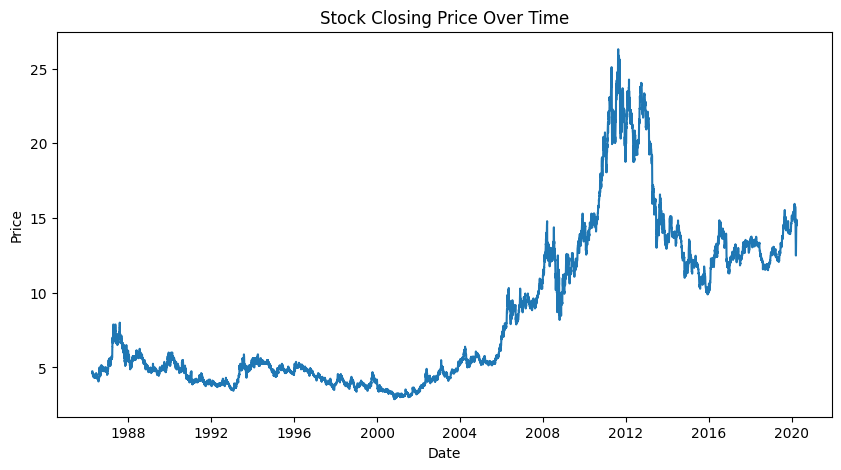

In [ ]:
# Plotting time series data

plt.figure(figsize=(10,5))
plt.plot(data['Date'], data['Close'])
plt.title("Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

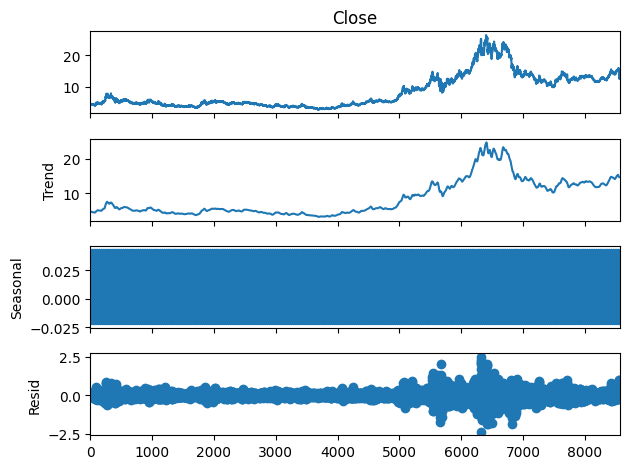

In [ ]:
# Checking trends and seasonality

result = seasonal_decompose(data['Close'], model='additive', period=30)
fig = result.plot()
plt.show()

**Trend:** The data shows  clear upward trajectory over time.

**Seasonality:** The graphs shows a solid block of blue. This usually happens when the data has a very high-frequency seasonal pattern relative to the total number of points. This suggests there is a very small, consistent oscillation—in this case, ranging roughly between -0.025 and +0.025.

**Residual:** The increased clustering (volatility) between 5,000 and 7,000 signifies that during the "spike" in the trend, the data became much more unpredictable and deviated further from its typical patterns.

In [ ]:
# stationarity tests

# 1. Augmented Dickey Fuller Test
print("1. p-value using Augmented Dickey Fuller Test:", adfuller(data['Close'])[1])

# 2. KPSS Test
print("2. p-value using KPSS Test:", kpss(data['Close'])[1])

1. p-value using Augmented Dickey Fuller Test: 0.6611462867737746
2. p-value using KPSS Test: 0.01


/tmp/ipykernel_5578/3496549259.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  print("2. p-value using KPSS Test:", kpss(data['Close'])[1])


Since p-value using the Augmented Dickey Fuller Test is greater than 0.05 and p-value using KPSS is less than 0.05, therefore the data is **non-stationary**.

##### **1.3 Data Preprocessing**

In [ ]:
# Preprocessing data

def preprocess_timeseries(data, train_size=0.85):
    """
    Preprocess time series data

    Args:
        data: raw time series data
        train_size: Size of Training data

    Returns:
        preprocessed data, scaler
    """
    # 1. Handle missing values
    data = data.copy()
    data = data.fillna(method='ffill')  # forward fill
    data = data.dropna()  # drop any remaining

    values = data[['Close']].values

    # Train-test split (temporal)
    split = int(len(values) * train_size)
    train, test = values[:split], values[split:]
    print("Train data shape:", train.shape)
    print("Test data shape:", test.shape)

    # Fit scaler ONLY on train
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train)
    test_scaled = scaler.transform(test)

    return train_scaled, test_scaled, scaler

In [ ]:
# Creating Sequences
def create_sequences(data, seq_length, pred_horizon):
    """
    Create sequences for time series prediction

    Args:
        data: preprocessed time series data
        seq_length: lookback window
        pred_horizon: forecast steps ahead

    Returns:
        X: input sequences, y: target values
    """
    X, y = [], []

    for i in range(len(data) - seq_length - pred_horizon + 1):
        # Input sequence
        X.append(data[i : i + seq_length])

        # Target sequence
        y.append(data[i + seq_length : i + seq_length + pred_horizon])

    X = np.array(X)
    y = np.array(y)

    return X, y

In [ ]:
train_scaled, test_scaled, scaler = preprocess_timeseries(data, 0.85)
X, y = create_sequences(train_scaled, sequence_length, prediction_horizon)

Train data shape: (7282, 1)
Test data shape: (1286, 1)


/tmp/ipykernel_5578/35755608.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='ffill')  # forward fill


In [ ]:
# REQUIRED: Temporal train/test split (NO SHUFFLING)
train_test_ratio = "85/15"
train_samples = 7282  # TODO: Number of training sequences
test_samples = 1286  # TODO: Number of test sequences

print(f"\nTrain/Test Split: {train_test_ratio}")
print(f"Training Samples: {train_samples}")
print(f"Test Samples: {test_samples}")
print("  IMPORTANT: Temporal split used (NO shuffling)")


Train/Test Split: 85/15
Training Samples: 7282
Test Samples: 1286
  IMPORTANT: Temporal split used (NO shuffling)


### **PART 2: LSTM/GRU Implementation**

##### **2.1 LSTM/GRU Architecture Design**

In [ ]:
# Designing architecture with stacked layers

def build_rnn_model(model_type, input_shape, hidden_units, n_layers, output_size):
    """
    Build LSTM or GRU model

    Args:
        model_type: string ('LSTM' or 'GRU')
        input_shape: tuple (sequence_length, n_features)
        hidden_units: number of hidden units per layer
        n_layers: number of stacked layers (minimum 2)
        output_size: prediction horizon

    Returns:
        model: compiled RNN model
    """
    model = Sequential()

    # Choose layer type
    RNN = GRU if model_type == 'GRU' else LSTM

    # First layer (needs input shape)
    model.add(RNN(hidden_units, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))

    # Middle stacked layers
    for _ in range(n_layers - 2):
        model.add(RNN(hidden_units, return_sequences=True))
        model.add(Dropout(0.2))

    # Last RNN layer (NO return_sequences)
    model.add(RNN(hidden_units, return_sequences=False))
    model.add(Dropout(0.2))

    # Output layer
    model.add(Dense(output_size))

    return model

# Creating RNN model
rnn_model = build_rnn_model('GRU', (sequence_length, n_features), 64, 2, prediction_horizon)

# Compiling model
rnn_model.compile(optimizer='adam', loss='mse', metrics=[RootMeanSquaredError(name='rmse'), 'mae'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


##### **2.2 Train RNN Model**

In [ ]:
print("\nRNN MODEL TRAINING")
# Track training time
rnn_start_time = time.time()

# TODO: Train your model
history_rnn = rnn_model.fit(X, y, epochs=50, batch_size=32)

rnn_training_time = time.time() - rnn_start_time


RNN MODEL TRAINING
Epoch 1/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - loss: 0.0037 - mae: 0.0291 - rmse: 0.0607
Epoch 2/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - loss: 8.8895e-04 - mae: 0.0179 - rmse: 0.0298
Epoch 3/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 7.4615e-04 - mae: 0.0163 - rmse: 0.0273
Epoch 4/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - loss: 7.6438e-04 - mae: 0.0165 - rmse: 0.0276
Epoch 5/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - loss: 6.2340e-04 - mae: 0.0146 - rmse: 0.0250
Epoch 6/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - loss: 6.1103e-04 - mae: 0.0150 - rmse: 0.0247
Epoch 7/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - loss: 5.4920e-04 - mae: 0.0140 - rmse: 0.0234
Epoch 8/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - loss: 5.5807e-04 - mae: 0.0147 - rmse: 0.0236
Epoch 9/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 4.9743e-04 - mae: 0.0136 - rmse: 0.0223
Epoch 10/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - loss: 5.098

In [ ]:
# REQUIRED: Track initial and final loss
rnn_initial_loss = 0.0030  # TODO: Get from training history (first epoch)
rnn_final_loss = 3.7302e-04  # TODO: Get from training history (last epoch)

print(f"Training completed in {rnn_training_time:.2f} seconds")
print(f"Initial Loss: {rnn_initial_loss:.4f}")
print(f"Final Loss: {rnn_final_loss:.4f}")

Training completed in 627.12 seconds
Initial Loss: 0.0030
Final Loss: 0.0004


##### **2.3 Evaluate RNN Model**

In [ ]:
# Creating Test Sequence
X_test, y_test = create_sequences(test_scaled, sequence_length, prediction_horizon)

# Making Predictions
y_pred_rnn = rnn_model.predict(X_test)

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


In [ ]:
y_test.shape # We will reshape y_test  y_pred since y_test is 3D, but inverse_transform expect 2D

(1256, 1, 1)

In [ ]:
# Inverse transforming the test data
y_test_2d = y_test.reshape(-1, 1)
y_test_inv = scaler.inverse_transform(y_test_2d)

y_pred_2d_rnn = y_pred_rnn.reshape(-1, 1)
y_pred_inv_rnn = scaler.inverse_transform(y_pred_2d_rnn)

In [ ]:
# Metric Calculation
rnn_mae = mean_absolute_error(y_test_inv, y_pred_inv_rnn)
rnn_rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv_rnn))
rnn_mape = np.mean(abs(y_test_inv - y_pred_inv_rnn) / abs(y_test_inv)) * 100
rnn_r2 = r2_score(y_test_inv, y_pred_inv_rnn)

print("\nRNN Model Performance:")
print(f"MAE:   {rnn_mae:.4f}")
print(f"RMSE:  {rnn_rmse:.4f}")
print(f"MAPE:  {rnn_mape:.4f}%")
print(f"R² Score: {rnn_r2:.4f}")


RNN Model Performance:
MAE:   0.1571
RMSE:  0.2072
MAPE:  1.2374%
R² Score: 0.9696


##### **2.4 Visualize RNN Results**

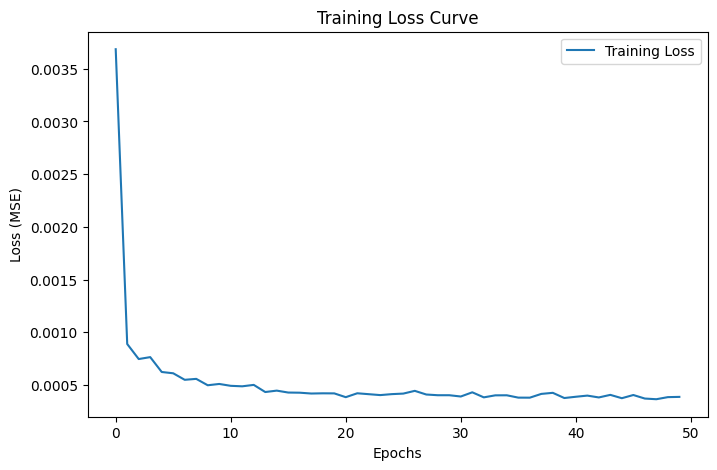

In [ ]:
# Plotting training loss curve
plt.figure(figsize=(8,5))
plt.plot(history_rnn.history['loss'], label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss Curve')
plt.legend()
plt.show()

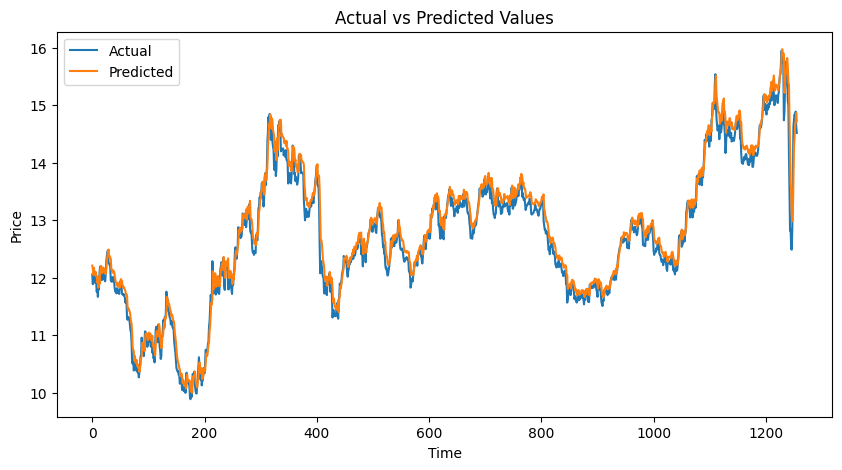

In [ ]:
# Plotting actual vs predicted values
plt.figure(figsize=(10,5))

plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_inv_rnn, label='Predicted')

plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Actual vs Predicted Values')

plt.legend()
plt.show()

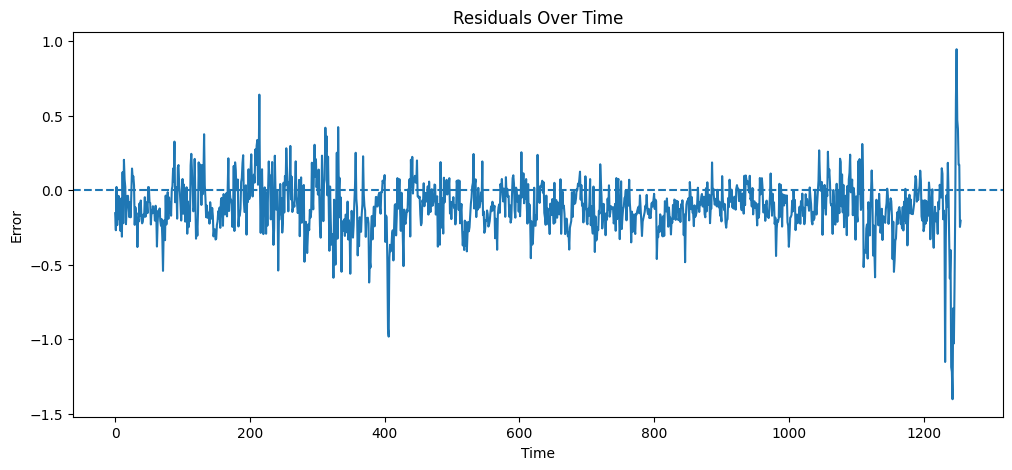

In [ ]:
# Plotting residuals
residuals = y_test_inv - y_pred_inv_rnn

plt.figure(figsize=(12,5))
plt.plot(residuals)

plt.axhline(y=0, linestyle='--')  # zero line

plt.title('Residuals Over Time')
plt.xlabel('Time')
plt.ylabel('Error')

plt.show()

### **PART 3: Transforfer Implementation**

##### **3.1 Positional Encoding Implementation**

In [ ]:
# Implementing sinusoidal positional encoding

def positional_encoding(seq_length, d_model):
    """
    Generate sinusoidal positional encodings

    Args:
        seq_length: length of the sequence
        d_model: dimension of the model

    Returns:
        positional encodings: array of shape (seq_length, d_model)
    """
    import numpy as np

    # Initialize matrix
    PE = np.zeros((seq_length, d_model))

    # Position indices (0 to seq_length-1)
    pos = np.arange(seq_length).reshape(-1, 1)

    # Dimension indices (0 to d_model-1)
    i = np.arange(d_model).reshape(1, -1)

    # Compute denominator term
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / d_model)

    # Compute angle values
    angle_rads = pos * angle_rates

    # Apply sin to even indices (2i)
    PE[:, 0::2] = np.sin(angle_rads[:, 0::2])

    # Apply cos to odd indices (2i+1)
    PE[:, 1::2] = np.cos(angle_rads[:, 1::2])

    return PE

##### **3.2 Transformer Encoder Architecture**

In [ ]:
# Using Keras
class TransformerEncoderBlock(Layer):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super().__init__()

        self.attention = MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads
        )

        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation='relu'),
            Dense(d_model)
        ])

        self.norm1 = LayerNormalization(epsilon=1e-6)
        self.norm2 = LayerNormalization(epsilon=1e-6)

        self.dropout1 = Dropout(dropout)
        self.dropout2 = Dropout(dropout)

    def call(self, x, training=False):
        attn_out = self.attention(x, x)
        attn_out = self.dropout1(attn_out, training=training)
        x = self.norm1(x + attn_out)

        ffn_out = self.ffn(x)
        ffn_out = self.dropout2(ffn_out, training=training)

        return self.norm2(x + ffn_out)

##### **3.3 Build Your Transformer Model**

In [ ]:
def build_transformer_model(seq_length, n_features, d_model=64, n_heads=4, d_ff=128, n_layers=2, output_size=1):


    inputs = Input(shape=(seq_length, n_features))

    # 1. Project input
    x = Dense(d_model)(inputs)

    # 2. Add positional encoding
    pe = positional_encoding(seq_length, d_model)
    x = x + pe

    # 3. Encoder stack
    for _ in range(n_layers):
        x = TransformerEncoderBlock(d_model, n_heads, d_ff)(x)

    # 4. Pooling
    x = GlobalAveragePooling1D()(x)

    outputs = Dense(output_size)(x)

    model = Model(inputs, outputs)

    return model

In [ ]:
# Creating Transformer model using PyTorch or Keras
transformer_model = build_transformer_model(sequence_length, n_features, d_model=64, n_heads=4, n_layers=2, d_ff=256, output_size=prediction_horizon)

# TODO: Define optimizer and loss
transformer_model.compile(optimizer='adam', loss='mse', metrics=['mae'])


##### **3.4 Train Transformer Model**

In [ ]:
print("\nTRANSFORMER MODEL TRAINING")
# Track training time
transformer_start_time = time.time()

# Train the model
history_tr = transformer_model.fit(X, y, epochs=50, batch_size=32)

transformer_training_time = time.time() - transformer_start_time


TRANSFORMER MODEL TRAINING
Epoch 1/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 21s 56ms/step - loss: 0.0668 - mae: 0.1159
Epoch 2/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - loss: 0.0020 - mae: 0.0349
Epoch 3/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - loss: 0.0017 - mae: 0.0325
Epoch 4/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - loss: 0.0014 - mae: 0.0293
Epoch 5/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - loss: 0.0012 - mae: 0.0275
Epoch 6/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - loss: 8.6555e-04 - mae: 0.0232
Epoch 7/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - loss: 7.0046e-04 - mae: 0.0209
Epoch 8/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - loss: 6.0359e-04 - mae: 0.0194
Epoch 9/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - loss: 7.5335e-04 - mae: 0.0218
Epoch 10/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - loss: 5.2137e-04 - mae: 0.0180
Epoch 11/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - loss: 6.2663e-04 - mae: 0.0198
Epoch 12/50
227/227 ━━━━━━━━━━━━━

In [ ]:
# Tracking initial and final loss
transformer_initial_loss = 0.0017  # from training history (first epoch)
transformer_final_loss = 1.7075e-04  # from training history (last epoch)

print(f"Training completed in {transformer_training_time:.2f} seconds")
print(f"Initial Loss: {transformer_initial_loss:.4f}")
print(f"Final Loss: {transformer_final_loss:.4f}")

Training completed in 734.54 seconds
Initial Loss: 0.0017
Final Loss: 0.0002


##### **3.5 Evaluate Transformer Model**

In [ ]:
# Creating Test Sequence
X_test, y_test = create_sequences(test_scaled, sequence_length, prediction_horizon)

# Making Predictions
y_pred_tr = transformer_model.predict(X_test)

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


In [ ]:
y_test.shape # We will reshape y_test  y_pred since y_test is 3D, but inverse_transform expect 2D

(1256, 1, 1)

In [ ]:
# Inverse transforming the test data
y_test_2d = y_test.reshape(-1, 1)
y_test_inv = scaler.inverse_transform(y_test_2d)

y_pred_2d_tr = y_pred_tr.reshape(-1, 1)
y_pred_inv_tr = scaler.inverse_transform(y_pred_2d_tr)

In [ ]:
# Metric Calculation
transformer_mae = mean_absolute_error(y_test_inv, y_pred_inv_tr)
transformer_rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv_tr))
transformer_mape = np.mean(abs(y_test_inv - y_pred_inv_tr) / abs(y_test_inv)) * 100
transformer_r2 = r2_score(y_test_inv, y_pred_inv_tr)

print("\nTransformer Model Performance:")
print(f"MAE:   {transformer_mae:.4f}")
print(f"RMSE:  {transformer_rmse:.4f}")
print(f"MAPE:  {transformer_mape:.4f}%")
print(f"R² Score: {transformer_r2:.4f}")


Transformer Model Performance:
MAE:   0.2363
RMSE:  0.2741
MAPE:  1.8606%
R² Score: 0.9469


##### **3.6 Visualize Transformer Results**

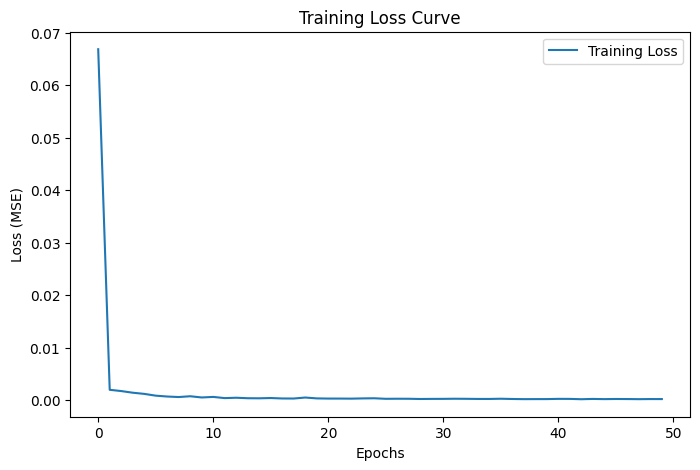

In [ ]:
# Plotting training loss curve
plt.figure(figsize=(8,5))
plt.plot(history_tr.history['loss'], label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss Curve')
plt.legend()
plt.show()

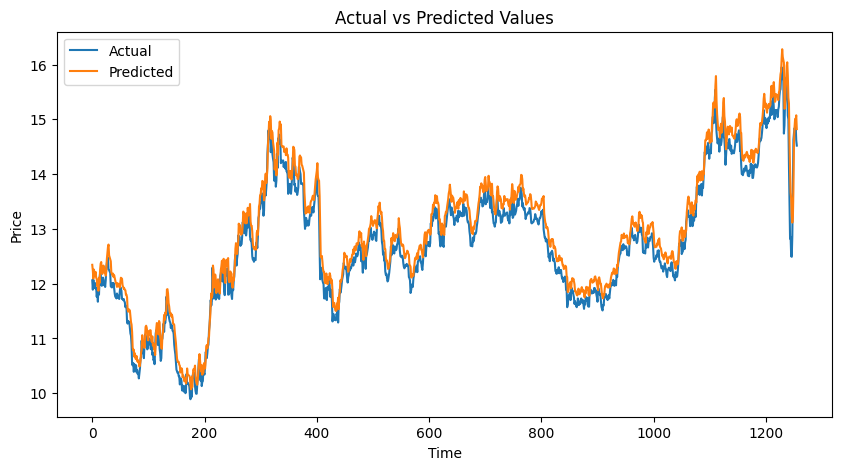

In [ ]:
# Plotting actual vs predicted values
plt.figure(figsize=(10,5))

plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_inv_tr, label='Predicted')

plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Actual vs Predicted Values')

plt.legend()
plt.show()

### **PART 4: Model Compaison and Visualization**

##### **4.1 Metrics Comparison**

In [ ]:
comparison_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE (%)', 'R² Score', 'Training Time (s)', 'Parameters'],
    'RNN (LSTM/GRU)': [
        rnn_mae,
        rnn_rmse,
        rnn_mape,
        rnn_r2,
        rnn_training_time,
        12545  # TODO: Fill with RNN total parameters
    ],
    'Transformer': [
        transformer_mae,
        transformer_rmse,
        transformer_mape,
        transformer_r2,
        transformer_training_time,
        67137  # TODO: Fill with Transformer total parameters
    ]
})

print(comparison_df.to_string(index=False))

           Metric  RNN (LSTM/GRU)  Transformer
              MAE        0.157118     0.236322
             RMSE        0.207228     0.274091
         MAPE (%)        1.237420     1.860555
         R² Score        0.969623     0.946858
Training Time (s)      627.116886   734.541539
       Parameters    12545.000000 67137.000000


##### **4.2 Visual Comparison**

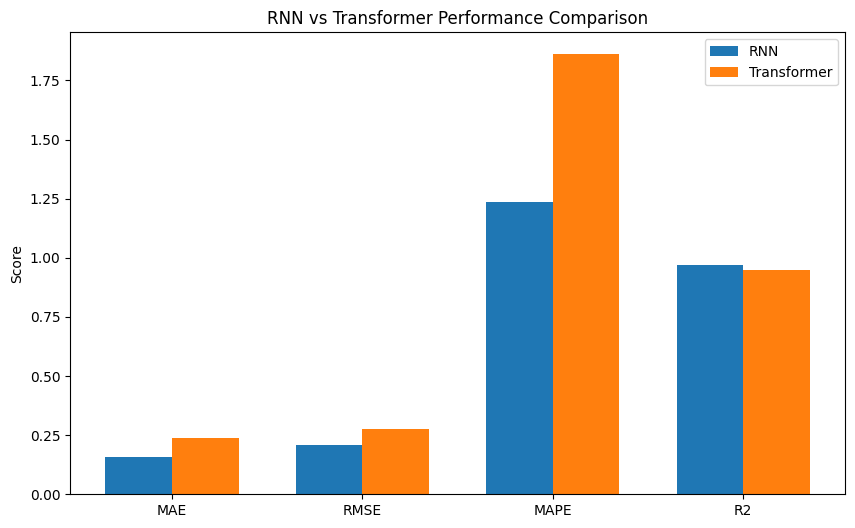

In [ ]:
# Bar plot to compare metrics
rnn_metrics = {"MAE": rnn_mae,
        "RMSE": rnn_rmse,
        "MAPE": rnn_mape,
        "R2": rnn_r2}

transformer_metrics = {"MAE": transformer_mae,
        "RMSE": transformer_rmse,
        "MAPE": transformer_mape,
        "R2": transformer_r2}

metrics = list(rnn_metrics.keys())

rnn_values = list(rnn_metrics.values())
transformer_values = list(transformer_metrics.values())

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(x - width/2, rnn_values, width, label='RNN')
plt.bar(x + width/2, transformer_values, width, label='Transformer')

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("RNN vs Transformer Performance Comparison")
plt.legend()

plt.show()

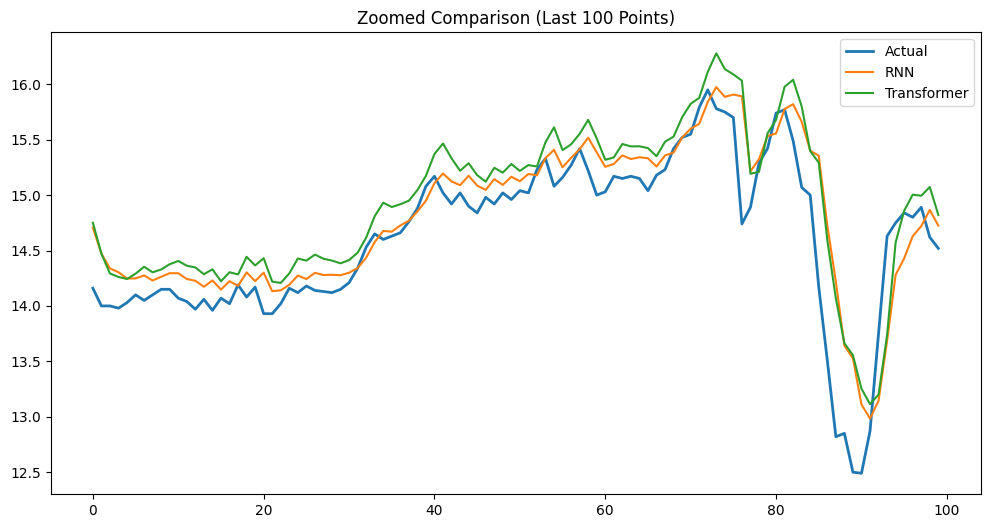

In [ ]:
# Plotting predictions comparison (both models vs actual)
plt.figure(figsize=(12,6))

plt.plot(y_test_inv[-100:], label='Actual', linewidth=2)
plt.plot(y_pred_inv_rnn[-100:], label='RNN')
plt.plot(y_pred_inv_tr[-100:], label='Transformer')

plt.title("Zoomed Comparison (Last 100 Points)")
plt.legend()

plt.show()

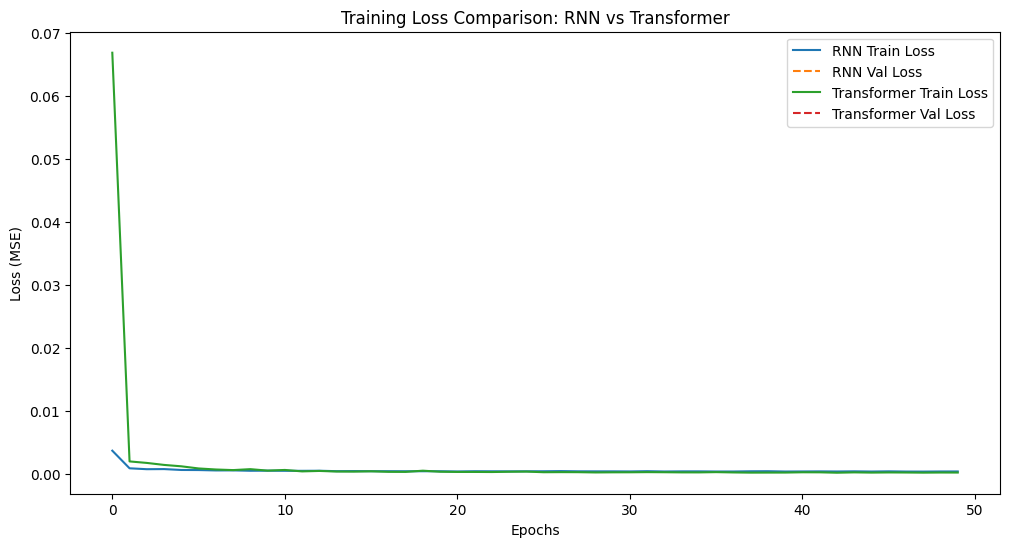

In [ ]:
# Plotting training curves comparison
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# RNN
plt.plot(history_rnn.history['loss'], label='RNN Train Loss')
plt.plot(history_rnn.history.get('val_loss', []), linestyle='--', label='RNN Val Loss')

# Transformer
plt.plot(history_tr.history['loss'], label='Transformer Train Loss')
plt.plot(history_tr.history.get('val_loss', []), linestyle='--', label='Transformer Val Loss')

plt.title("Training Loss Comparison: RNN vs Transformer")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()

plt.show()

### **PART 5: Assignment Results Summary**

In [ ]:
def get_assignment_results():
    """
    Generate complete assignment results in required format

    Returns:
        dict: Complete results with all required fields
    """

    framework_used = "keras"
    rnn_model_type = "GRU"

    results = {
        # Dataset Information
        'dataset_name': dataset_name,
        'dataset_source': dataset_source,
        'n_samples': n_samples,
        'n_features': n_features,
        'sequence_length': sequence_length,
        'prediction_horizon': prediction_horizon,
        'problem_type': problem_type,
        'primary_metric': primary_metric,
        'metric_justification': metric_justification,
        'train_samples': train_samples,
        'test_samples': test_samples,
        'train_test_ratio': train_test_ratio,

        # RNN Model Results
        'rnn_model': {
            'framework': framework_used,
            'model_type': rnn_model_type,
            'architecture': {
                'n_layers': 2,
                'hidden_units': 64,
                'total_parameters': 12545
            },
            'training_config': {
                'learning_rate': 0.001,
                'n_epochs': 50,
                'batch_size': 32,
                'optimizer': 'Adam',
                'loss_function': 'MSE'
            },
            'initial_loss': rnn_initial_loss,
            'final_loss': rnn_final_loss,
            'training_time_seconds': rnn_training_time,
            'mae': rnn_mae,
            'rmse': rnn_rmse,
            'mape': rnn_mape,
            'r2_score': rnn_r2
        },

        # Transformer Model Results
        'transformer_model': {
            'framework': framework_used,
            'architecture': {
                'n_layers': 2,
                'n_heads': 4,
                'd_model': 64,
                'd_ff': 128,
                'has_positional_encoding': True,
                'has_attention': True,
                'total_parameters': 67137  # TODO: Calculate total parameters
            },
            'training_config': {
                'learning_rate': 0.001,
                'n_epochs': 50,
                'batch_size': 32,
                'optimizer': 'Adam',
                'loss_function': 'MSE'
            },
            'initial_loss': transformer_initial_loss,
            'final_loss': transformer_final_loss,
            'training_time_seconds': transformer_training_time,
            'mae': transformer_mae,
            'rmse': transformer_rmse,
            'mape': transformer_mape,
            'r2_score': transformer_r2
        },

        # Analysis
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),

        # Training Success Indicators
        'rnn_loss_decreased': rnn_final_loss < rnn_initial_loss if rnn_initial_loss and rnn_final_loss else False,
        'transformer_loss_decreased': transformer_final_loss < transformer_initial_loss if transformer_initial_loss and transformer_final_loss else False,
    }

    return results

# Generate and print results
try:
    assignment_results = get_assignment_results()
    print("ASSIGNMENT RESULTS SUMMARY")
    print(json.dumps(assignment_results, indent=2))
except Exception as e:
    print(f"\n  ERROR generating results: {str(e)}")
    print("Please ensure all variables are properly defined")

ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Stock Market Dataset (CEF)",
  "dataset_source": "Kaggle (https://www.kaggle.com/datasets/jacksoncrow/stock-market-dataset)",
  "n_samples": 8568,
  "n_features": 1,
  "sequence_length": 30,
  "prediction_horizon": 1,
  "problem_type": "time_series_forecasting",
  "primary_metric": "RMSE",
  "metric_justification": "\n1. Penalizes large errors more which is critical in financial forecasting where large prediction errors carry higher risk.\n2. Standard in time series forecasting.\n",
  "train_samples": 7282,
  "test_samples": 1286,
  "train_test_ratio": "85/15",
  "rnn_model": {
    "framework": "keras",
    "model_type": "GRU",
    "architecture": {
      "n_layers": 2,
      "hidden_units": 64,
      "total_parameters": 12545
    },
    "training_config": {
      "learning_rate": 0.001,
      "n_epochs": 50,
      "batch_size": 32,
      "optimizer": "Adam",
      "loss_function": "MSE"
    },
    "initial_loss": 0.003,
    "final_loss":

**ENVIRONMENT VERIFICATION - SCREENSHOT REQUIRED**

**IMPORTANT:** Take a screenshot of your environment showing account details

**For Google Colab:**
- Click on your profile icon (top right)
- Screenshot should show your email/account clearly
- Include the entire Colab interface with notebook name visible

**For BITS Virtual Lab:**
- Screenshot showing your login credentials/account details
- Include the entire interface with your username/session info visible

Paste the screenshot below this cell or in a new markdown cell.
This helps verify the work was done by you in your environment.

In [ ]:
# Display system information
import platform
import sys
from datetime import datetime

# +
print("ENVIRONMENT INFORMATION")
print("\nREQUIRED: Add screenshot of your Google Colab/BITS Virtual Lab")
print("showing your account details in the cell below this one.")

ENVIRONMENT INFORMATION

REQUIRED: Add screenshot of your Google Colab/BITS Virtual Lab
showing your account details in the cell below this one.


**Include the screen shot here**

# **END OF SCRIPT**